In [1]:
import numpy as np
import matplotlib.pyplot as plt

# TaylorT2 from personal implementation in  https://github.com/dig07/Waveform_implementations 
import TaylorT2
import jax.numpy as jnp
import scienceplots
import matplotlib 

plt.style.use('science')
matplotlib.rcParams.update({'font.size': 15})

In [3]:
from lisaconstants import NEWTON_CONSTANT, GM_SUN, PARSEC_METER, c

import jax
##### Physical constants #####
G = NEWTON_CONSTANT
GM_sun = GM_SUN
pc = PARSEC_METER
MTsun = GM_sun/c**3 

In [4]:
f_min = 0.001
f_max = 0.1

In [5]:
T_obs = 2*365.25*24*60*60
dF = 1/T_obs
freqs = np.arange(f_min,f_max,dF)

In [6]:
constant_eta = 0.25 # Equal masses for simplicity
inc = 0.0 # face-on # Irrelevant 
phi_ref = 0.0 # Irrelevant
e0 = 0.0 # Circular (initially)
distance = 0.0  # Irrelevant
s1 =0.0 # No spins (May matter)
s2 =0.0 # No spins (May matter)

In [7]:
@jax.jit
def component_masses_from_chirp_eta(mchirp, eta):
    """
    Calculate the component masses of a binary system from the chirp mass and symmetric mass ratio.

    Parameters:
        mchirp (float): The chirp mass of the binary system.
        eta (float): The symmetric mass ratio of the binary system.

    Returns:
        tuple: A tuple containing the component masses (m1, m2) of the binary system.
    """
    mtotal = mchirp / eta**(3/5)
    m1 = 0.5 * mtotal * (1.0 + (1.0 - 4.0 * eta)**0.5)
    m2 = 0.5 * mtotal * (1.0 - (1.0 - 4.0 * eta)**0.5)
    return m1, m2

In [8]:
T_obs/(365.25*24*60*60)

2.0

In [9]:
dF = 1/(3*3600) # Frequency resolution for 3 hours of observation
dT = 3*3600  # 3 hours in seconds

In [10]:
t_grid = jnp.arange(0, T_obs, 1.0/dF)
t_grid/(365.25*24*60*60)  # in years


Array([0.00000000e+00, 3.42231348e-04, 6.84462697e-04, ...,
       1.99897331e+00, 1.99931554e+00, 1.99965777e+00], dtype=float64)

In [11]:
@jax.jit
def compute_f_dot(mc, f_low):

    m1, m2 = component_masses_from_chirp_eta(mc, constant_eta)

    f_0 = f_low

    m1 = m1*MTsun
    m2 = m2*MTsun
    M = m1 + m2

    eta = (m1*m2)/(M)**2

    v0 = (jnp.pi*M*f_0)**(1/3)

    # Work out time to merger from f_low
    tc = 5*M/(256*eta*v0**(8))*TaylorT2.CPU_old.calculate_tau(v0,v0,e0,eta)

    # Evaluate f(t) over the entire observation time
    f_t_T3 = 1/(8*jnp.pi*M)*jax.vmap(TaylorT2.CPU_old.calculate_Xi, in_axes = (0,None,None,None,None))(t_grid,tc,M,eta,e0)  

    f_dot_function = jax.grad(TaylorT2.CPU_old.calculate_Xi, argnums=0)

    # Compute f_dot and f_ddot over the entire t_grid (fixed size for JIT)
    f_dot_T3 = 1/(8*jnp.pi*M)*jax.vmap(f_dot_function, in_axes=(0, None, None, None, None))(t_grid, tc, M, eta, e0)
    
    f_ddot_T3 = 1/(8*jnp.pi*M)*jax.vmap(jax.grad(f_dot_function, argnums=0), in_axes=(0, None, None, None, None))(t_grid, tc, M, eta, e0)

    # Create a mask for valid entries: t < tc AND f < 0.1 Hz
    valid_mask = (t_grid < tc) & (f_t_T3 < 0.1)
    
    # Replace invalid entries with -inf (for max) or 0 (for sum) so they don't affect results
    f_dot_masked = jnp.where(valid_mask, f_dot_T3, -jnp.inf)
    f_ddot_masked = jnp.where(valid_mask, f_ddot_T3, -jnp.inf)
    
    return f_dot_masked, f_ddot_masked, valid_mask

In [12]:
# Test the JIT-compiled function
f_dot_test, f_ddot_test, mask_test = compute_f_dot(40.0, 0.011)
print(f"Max f_dot (valid): {jnp.max(f_dot_test)}")
print(f"Max f_ddot (valid): {jnp.max(f_ddot_test)}")
print(f"Number of valid time points: {jnp.sum(mask_test)}")

Max f_dot (valid): 2.7604624132583692e-11
Max f_ddot (valid): 2.25358065364373e-19
Number of valid time points: 5844


In [13]:
one_month_in_seconds = 4 * 7 * 24 * 60 * 60

In [20]:
# High frequency tiles 

N_max = 1620

V_posterior_analog = []
mc_prior_master = []
f_low_priors_master = []
f_dot_master = []
f_ddot_master = []

f_dot_master_number = []
f_ddot_master_number = []

for i in range(N_max):
    tile_priors  = np.loadtxt(f'/Users/diganta/Desktop/Papers/Full_search/Tile_gen/{i}.txt')
    
    f_low_priors = tile_priors[0]
    mc_priors = tile_priors[1]

    # Midpoint of f_low and mc 
    midpoint_f_low = np.mean(f_low_priors)
    midpoint_mc = np.mean(mc_priors)

    # Compute f_dot and f_ddot at the midpoint values, along with the valid mask
    f_dot_masked, f_ddot_masked, valid_mask = compute_f_dot(midpoint_mc, midpoint_f_low)

    mc_prior_master.append(mc_priors)
    f_low_priors_master.append(f_low_priors)

    # Use max over valid entries (invalid are -inf, so they won't affect max)
    f_dot_master.append(jnp.max(f_dot_masked))
    # f_ddot_master.append(jnp.max(f_ddot_masked))

    # Count using the mask: sum where (condition is met AND entry is valid)
    f_dot_exceeds = (f_dot_masked * dT > 10 * dF) & valid_mask
    
    f_dot_master_number.append(jnp.sum(f_dot_exceeds)/valid_mask.sum())
    # f_ddot_master_number.append(jnp.sum(f_ddot_exceeds)/valid_mask.sum())

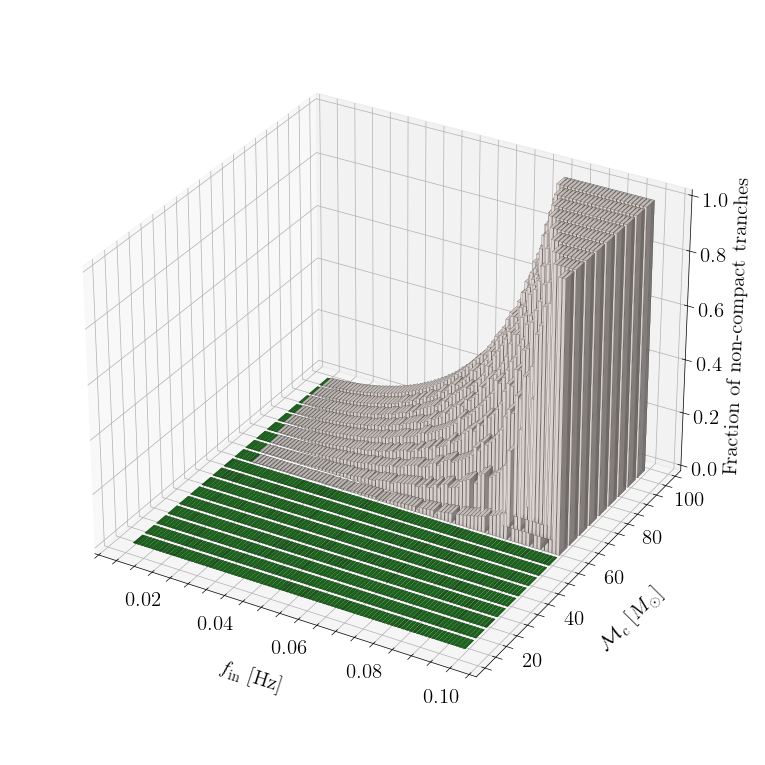

In [ ]:
# 3D bar chart for f_dot_master_number only
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))

# Get tile midpoints for positioning
f_low_midpoints = np.array([np.mean(f_low_priors_master[i]) for i in range(N_max)])
mc_midpoints = np.array([np.mean(mc_prior_master[i]) for i in range(N_max)])

# Bar dimensions (based on tile sizes)
df_bar = 0.001 * 0.8  # slightly smaller than tile width
dmc_bar = 5 * 0.8  # slightly smaller than tile height

ax = fig.add_subplot(111, projection='3d')

# Create bars
for i in range(N_max):
    x = f_low_midpoints[i]
    y = mc_midpoints[i]
    z = 0
    dx = df_bar
    dy = dmc_bar
    dz = float(f_dot_master_number[i])
    
    # Color based on value (higher = more problematic)
    if dz > 0:
        color = plt.cm.Reds(min(dz / 1000, 1.0))
    else:
        color = 'green'
    
    ax.bar3d(x, y, z, dx, dy, dz, color=color, alpha=0.7, edgecolor='k', linewidth=0.1)

ax.set_xlabel(r'$f_{\rm{in}}$ [Hz]', fontsize=15,labelpad=15)
ax.set_ylabel(r'$\mathcal{M}_c$ [$M_\odot$]', fontsize=15,labelpad=15)
ax.set_zlabel(r'Fraction of non-compact tranches', fontsize=15)
ax.set_box_aspect(None, zoom=0.90)

plt.tight_layout()
plt.savefig('3D_fdot_bar_chart.pdf')
plt.show()